# Project 10 -- Lukas Anell

In [1]:
# /anvil/projects/tdm/data/death_records/DeathRecords.csv

## Question 1

In [2]:
import pandas as pd

In [3]:
myDF = pd.read_csv("/anvil/projects/tdm/data/death_records/DeathRecords.csv")
myDF.head()

,Id,ResidentStatus,Education1989Revision,Education2003Revision,EducationReportingFlag,MonthOfDeath,Sex,AgeType,Age,AgeSubstitutionFlag,...,CauseRecode39,NumberOfEntityAxisConditions,NumberOfRecordAxisConditions,Race,BridgedRaceFlag,RaceImputationFlag,RaceRecode3,RaceRecode5,HispanicOrigin,HispanicOriginRaceRecode
0,1,1,0,2,1,1,M,1,87,0,...,24,1,1,1,0,0,1,1,100,6
1,2,1,0,2,1,1,M,1,58,0,...,21,3,3,1,0,0,1,1,100,6
2,3,1,0,7,1,1,F,1,75,0,...,28,2,2,1,0,0,1,1,100,6
3,4,1,0,6,1,1,M,1,74,0,...,22,3,3,1,0,0,1,1,100,6
4,5,1,0,3,1,1,M,1,64,0,...,21,1,1,1,0,0,1,1,100,6


In [4]:
race_decoder = pd.read_csv("/anvil/projects/tdm/data/death_records/Race.csv")
race_decoder.head()

,Code,Description
0,0,Other races
1,1,White
2,2,Black
3,3,American Indian (includes Aleuts and Eskimos)
4,4,Chinese


In [23]:
race_decoder.tail()

,Code,Description
11,38,Samoan
12,48,Vietnamese
13,58,Guamanian
14,68,Other Asian or Pacific Islander in areas repor...
15,78,"Combined other Asian or Pacific Islander, incl..."


In [6]:
maritalStatus_decoder = pd.read_csv("/anvil/projects/tdm/data/death_records/MaritalStatus.csv")
maritalStatus_decoder.head()

,Code,Description
0,S,"Never married, single"
1,M,Married
2,W,Widowed
3,D,Divorced
4,U,Marital Status unknown


In [19]:
race_counts = myDF['Race'].value_counts()
race_counts.sort_index()

Race
1     2241510
2      309504
3       18031
4       13297
5        8159
6         700
7       11074
18       6778
28       4711
38        623
48       4913
58        316
68       8737
78       2818
Name: count, dtype: int64

In [20]:
race_counts

Race
1     2241510
2      309504
3       18031
4       13297
7       11074
68       8737
5        8159
18       6778
48       4913
28       4711
78       2818
6         700
38        623
58        316
Name: count, dtype: int64

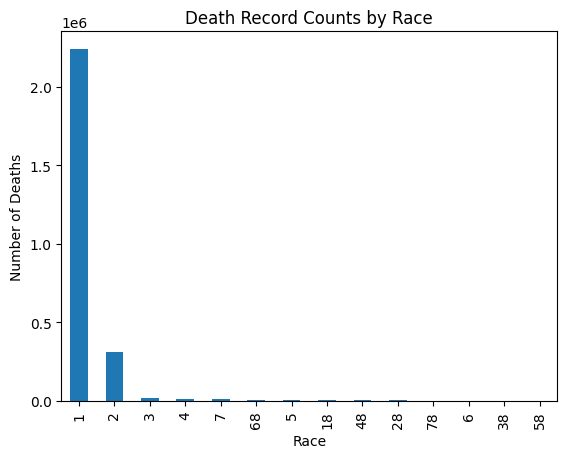

In [21]:
import matplotlib.pyplot as plt
race_counts.plot(kind='bar')
plt.title('Death Record Counts by Race')
plt.xlabel('Race')
plt.ylabel('Number of Deaths')
plt.show()

I wasn't sure whether or not I should try to use the decoder csv for the plot, so I chose not to.

1.1: I learned that the majority of the race column is white, with the runner up being black.

1.2: Anything that uses magic numbers like ResidentStatus would be interesting.

1.3: 58, which corresponds to Guamanian, had the least amount of entries.

## Question 2

In [24]:
filtered = myDF[myDF['Race'] != 1]
filtered.head()

,Id,ResidentStatus,Education1989Revision,Education2003Revision,EducationReportingFlag,MonthOfDeath,Sex,AgeType,Age,AgeSubstitutionFlag,...,CauseRecode39,NumberOfEntityAxisConditions,NumberOfRecordAxisConditions,Race,BridgedRaceFlag,RaceImputationFlag,RaceRecode3,RaceRecode5,HispanicOrigin,HispanicOriginRaceRecode
7,8,1,0,4,1,1,M,1,55,0,...,21,2,2,2,1,0,3,2,100,7
15,16,1,0,4,1,1,F,1,70,0,...,21,8,7,3,0,0,2,3,100,8
17,18,1,0,5,1,1,F,1,82,0,...,21,2,2,28,0,0,2,4,100,8
19,20,1,0,3,1,1,F,1,84,0,...,13,6,5,2,0,0,3,2,100,7
20,21,2,0,3,1,1,M,1,80,0,...,21,4,3,3,0,0,2,3,100,8


In [25]:
race_counts_filtered = filtered['Race'].value_counts()
race_counts_filtered

Race
2     309504
3      18031
4      13297
7      11074
68      8737
5       8159
18      6778
48      4913
28      4711
78      2818
6        700
38       623
58       316
Name: count, dtype: int64

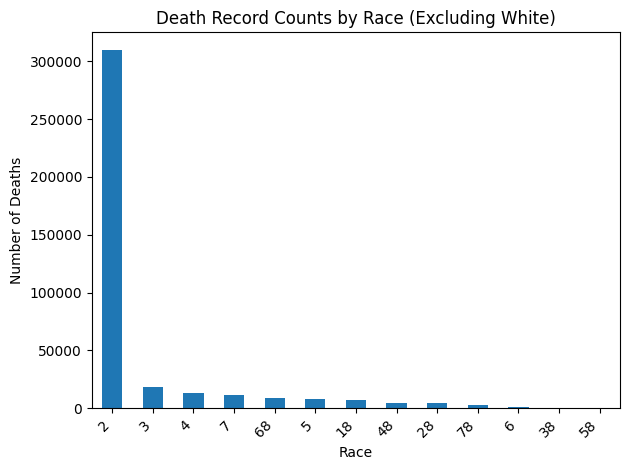

In [26]:
race_counts_filtered.plot(kind='bar')
plt.title('Death Record Counts by Race (Excluding White)')
plt.xlabel('Race')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [28]:
filtered2 = myDF[~myDF['Race'].isin([1, 2])]
filtered2.head()

,Id,ResidentStatus,Education1989Revision,Education2003Revision,EducationReportingFlag,MonthOfDeath,Sex,AgeType,Age,AgeSubstitutionFlag,...,CauseRecode39,NumberOfEntityAxisConditions,NumberOfRecordAxisConditions,Race,BridgedRaceFlag,RaceImputationFlag,RaceRecode3,RaceRecode5,HispanicOrigin,HispanicOriginRaceRecode
15,16,1,0,4,1,1,F,1,70,0,...,21,8,7,3,0,0,2,3,100,8
17,18,1,0,5,1,1,F,1,82,0,...,21,2,2,28,0,0,2,4,100,8
20,21,2,0,3,1,1,M,1,80,0,...,21,4,3,3,0,0,2,3,100,8
26,27,1,0,7,1,1,M,1,71,0,...,21,2,2,7,0,0,2,4,100,8
27,28,1,0,3,1,1,F,1,46,0,...,30,1,1,3,0,0,2,3,100,8


In [29]:
race_counts_filtered2 = filtered2['Race'].value_counts()
race_counts_filtered2

Race
3     18031
4     13297
7     11074
68     8737
5      8159
18     6778
48     4913
28     4711
78     2818
6       700
38      623
58      316
Name: count, dtype: int64

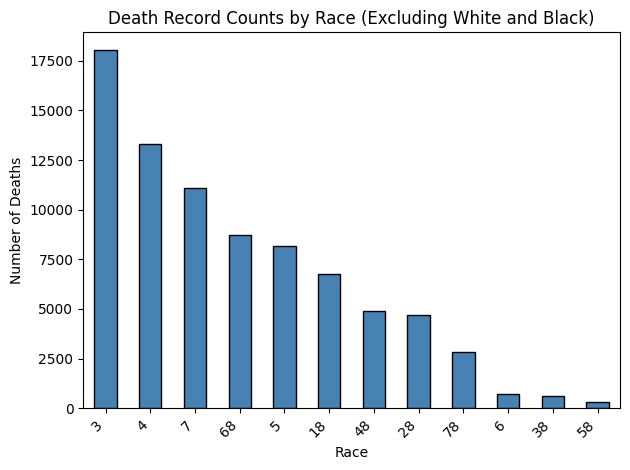

In [31]:
race_counts_filtered2.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Death Record Counts by Race (Excluding White and Black)')
plt.xlabel('Race')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

2.1: Not a ton, but I found that I like the color "steelblue" and giving the bars edges to separate them from the background better. I also like rotating the bar labels, which would make the labels fit better if they were longer.

2.2: The biggest thing is labelling the graphs. I wasn't sure about how to go about mapping the labels from the decoders onto the value_counts, but I'm sure I could figure it out.

2.3: I excluded the two largest groups, White and Black because they were making the counts of the other races lose meaning because they all looked the same despite having very different values.

## Question 3

In [32]:
import seaborn as sns

In [46]:
order  = ['S', 'M', 'W', 'D', 'U']

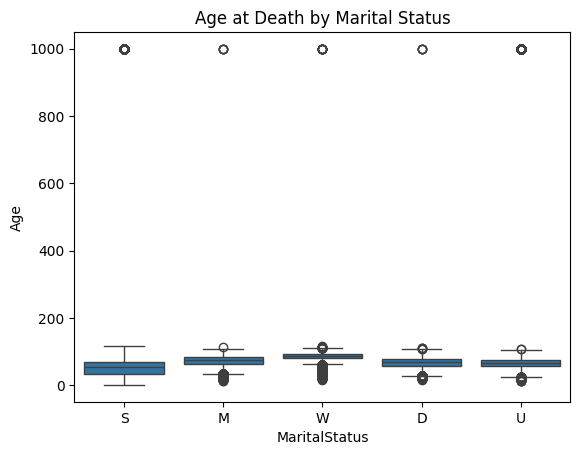

In [47]:
sns.boxplot(x='MaritalStatus', y='Age', data=myDF, order=order)
plt.title("Age at Death by Marital Status")
plt.show()

In [37]:
cleanDF = myDF[myDF['Age'] != 999]
cleanDF.head()

,Id,ResidentStatus,Education1989Revision,Education2003Revision,EducationReportingFlag,MonthOfDeath,Sex,AgeType,Age,AgeSubstitutionFlag,...,CauseRecode39,NumberOfEntityAxisConditions,NumberOfRecordAxisConditions,Race,BridgedRaceFlag,RaceImputationFlag,RaceRecode3,RaceRecode5,HispanicOrigin,HispanicOriginRaceRecode
0,1,1,0,2,1,1,M,1,87,0,...,24,1,1,1,0,0,1,1,100,6
1,2,1,0,2,1,1,M,1,58,0,...,21,3,3,1,0,0,1,1,100,6
2,3,1,0,7,1,1,F,1,75,0,...,28,2,2,1,0,0,1,1,100,6
3,4,1,0,6,1,1,M,1,74,0,...,22,3,3,1,0,0,1,1,100,6
4,5,1,0,3,1,1,M,1,64,0,...,21,1,1,1,0,0,1,1,100,6


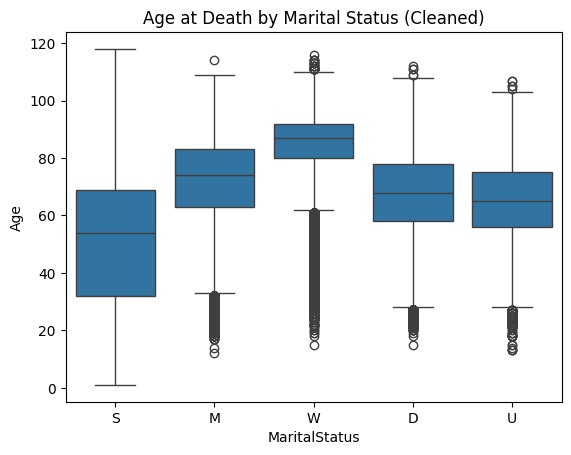

In [48]:
sns.boxplot(x='MaritalStatus', y='Age', data=cleanDF, order=order)
plt.title("Age at Death by Marital Status (Cleaned)")
plt.show()

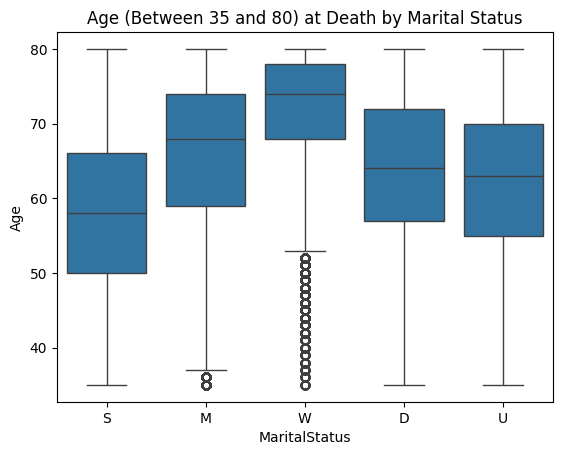

In [49]:
ageRangeDF = cleanDF[(cleanDF['Age'] >= 35) & (cleanDF['Age'] <= 80)]
sns.boxplot(x='MaritalStatus', y='Age', data=ageRangeDF, order=order)
plt.title("Age (Between 35 and 80) at Death by Marital Status")
plt.show()

3.1: See above.

3.2: The one including 999 was a lot more squished, as was said in the instructions. Without it, it was much easier to read the whisker plot and see the range and outliers.

3.3: The age range plot between 35-80 is just a zoomed in version of the one with the full age range, which means cutting out the very young and very old deaths. There are still a lot of similarities between the plots, but we can see how many outliers were removed by restricting the range.

## Question 4

In [50]:
cleanDF["MaritalStatus"].value_counts()

MaritalStatus
M    980012
W    898430
D    400955
S    332792
U     18411
Name: count, dtype: int64

In [57]:
subset = cleanDF[cleanDF['MaritalStatus'].isin(['M', 'W'])]
subset.head()

,Id,ResidentStatus,Education1989Revision,Education2003Revision,EducationReportingFlag,MonthOfDeath,Sex,AgeType,Age,AgeSubstitutionFlag,...,CauseRecode39,NumberOfEntityAxisConditions,NumberOfRecordAxisConditions,Race,BridgedRaceFlag,RaceImputationFlag,RaceRecode3,RaceRecode5,HispanicOrigin,HispanicOriginRaceRecode
0,1,1,0,2,1,1,M,1,87,0,...,24,1,1,1,0,0,1,1,100,6
2,3,1,0,7,1,1,F,1,75,0,...,28,2,2,1,0,0,1,1,100,6
5,6,1,0,5,1,1,F,1,93,0,...,37,5,5,1,0,0,1,1,100,6
6,7,1,0,4,1,1,M,1,82,0,...,21,4,3,1,0,0,1,1,100,6
8,9,1,0,3,1,1,F,1,86,0,...,37,1,1,1,0,0,1,1,100,6


/tmp/ipykernel_604/201913620.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


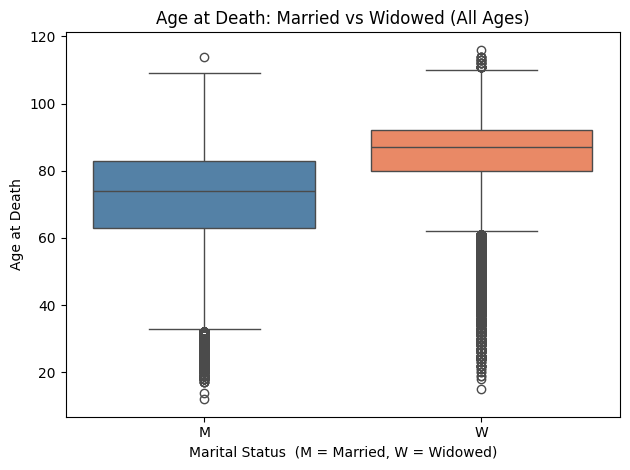

In [61]:
sns.boxplot(
    x='MaritalStatus',
    y='Age',
    data=subset,
    order=['M', 'W'],
    palette=['steelblue', 'coral']
)
plt.title('Age at Death: Married vs Widowed (All Ages)')
plt.xlabel('Marital Status  (M = Married, W = Widowed)')
plt.ylabel('Age at Death')
plt.tight_layout()
plt.show()

In [62]:
subset2 = subset[subset['Age'] == 60]
subset2.head()

,Id,ResidentStatus,Education1989Revision,Education2003Revision,EducationReportingFlag,MonthOfDeath,Sex,AgeType,Age,AgeSubstitutionFlag,...,CauseRecode39,NumberOfEntityAxisConditions,NumberOfRecordAxisConditions,Race,BridgedRaceFlag,RaceImputationFlag,RaceRecode3,RaceRecode5,HispanicOrigin,HispanicOriginRaceRecode
30,31,1,0,3,1,1,F,1,60,0,...,38,2,2,1,0,0,1,1,100,6
159,160,1,0,6,1,1,F,1,60,0,...,37,5,5,1,0,0,1,1,100,6
224,225,1,0,6,1,2,M,1,60,0,...,8,2,2,1,0,0,1,1,100,6
268,269,2,0,3,1,2,M,1,60,0,...,15,1,1,1,0,0,1,1,100,6
373,374,1,0,6,1,2,M,1,60,0,...,11,1,1,1,0,0,1,1,100,6


In [63]:
my_counts = subset2['MaritalStatus'].value_counts()
my_counts

MaritalStatus
M    16413
W     2711
Name: count, dtype: int64

/tmp/ipykernel_604/3235313146.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


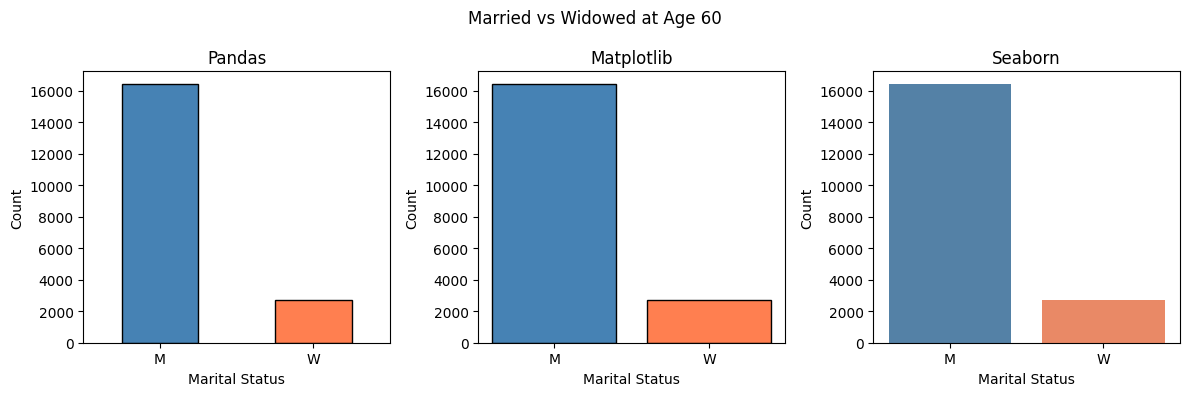

In [67]:
labels = my_counts.index
counts = my_counts.values

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
fig.suptitle('Married vs Widowed at Age 60')

# pd
my_counts.plot(
    kind='bar',
    ax=axes[0],
    color=['steelblue', 'coral'],
    edgecolor='black'
)
axes[0].set_title('Pandas')
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# plt
axes[1].bar(labels, counts, color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('Matplotlib')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Count')

# sns
sns.barplot(
    x=labels,
    y=counts,
    ax=axes[2],
    palette=['steelblue', 'coral']
)
axes[2].set_title('Seaborn')
axes[2].set_xlabel('Marital Status')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [68]:
subset3 = subset[subset['Age'] == 75]
my_counts2 = subset3['MaritalStatus'].value_counts()

/tmp/ipykernel_604/525685564.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


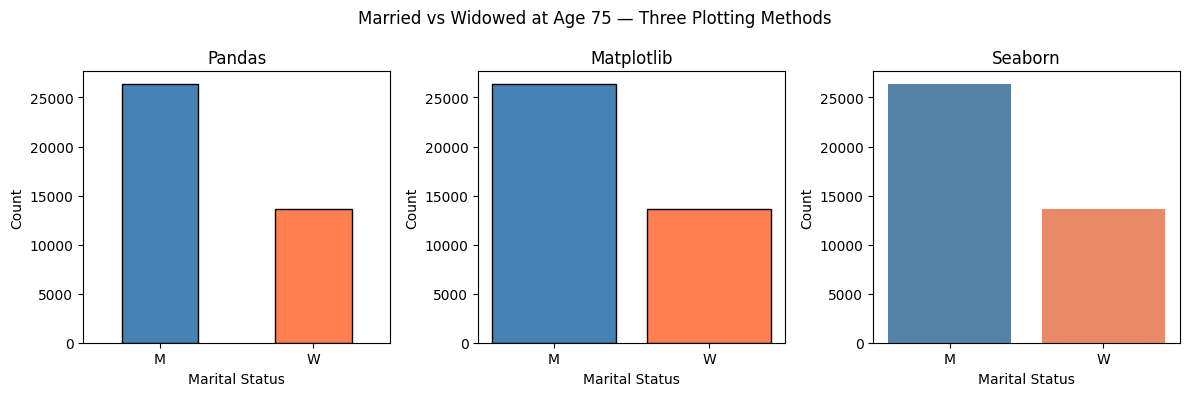

In [71]:
labels2 = my_counts2.index
counts2 = my_counts2.values

fig2, axes2 = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
fig2.suptitle('Married vs Widowed at Age 75 — Three Plotting Methods')

my_counts2.plot(
    kind='bar',
    ax=axes2[0],
    color=['steelblue', 'coral'],
    edgecolor='black'
)
axes2[0].set_title('Pandas')
axes2[0].set_xlabel('Marital Status')
axes2[0].set_ylabel('Count')
axes2[0].tick_params(axis='x', rotation=0)

axes2[1].bar(
    labels2,
    counts2,
    color=['steelblue', 'coral'],
    edgecolor='black'
)
axes2[1].set_title('Matplotlib')
axes2[1].set_xlabel('Marital Status')
axes2[1].set_ylabel('Count')

sns.barplot(
    x=labels2,
    y=counts2,
    ax=axes2[2],
    palette=['steelblue', 'coral']
)
axes2[2].set_title('Seaborn')
axes2[2].set_xlabel('Marital Status')
axes2[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

4.1: The widowed box is higher up than the married box, which means that the median age of death for widowed people is higher than that of married people. I think this makes sense because if you're widowed you're probably older because your partner had to die before you, on average.

4.2: Based on the plots for age 60 vs age 75, I think at age 60 a lot more people die while they're married, but when the age is 75, the amount of widowed deaths has grown significantly, almost being half of the married deaths. I would expect that gap to close as the age increases, but they should never be even I think?

4.3: There isn't much difference. Matplotlib and Seaborn seem to have much thicker bars and the colors look different between all 3, but other than that not a lot.

## Question 5

In [73]:
my_first_counts  = cleanDF[cleanDF['Age'] == 60]['MaritalStatus'].value_counts()
my_second_counts = cleanDF[cleanDF['Age'] == 70]['MaritalStatus'].value_counts()
my_third_counts  = cleanDF[cleanDF['Age'] == 80]['MaritalStatus'].value_counts()

In [74]:
bar_colors = ['#78b159', 'blue', 'red', 'green', 'yellow']

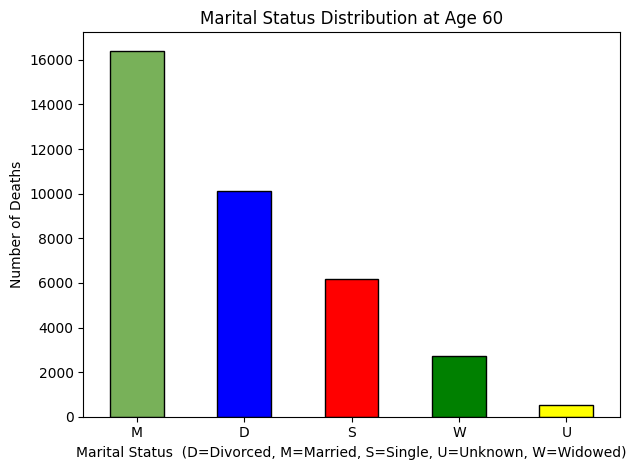

In [75]:
my_first_counts.plot(kind='bar', color=bar_colors, edgecolor='black')
plt.title('Marital Status Distribution at Age 60')
plt.xlabel('Marital Status  (D=Divorced, M=Married, S=Single, U=Unknown, W=Widowed)')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

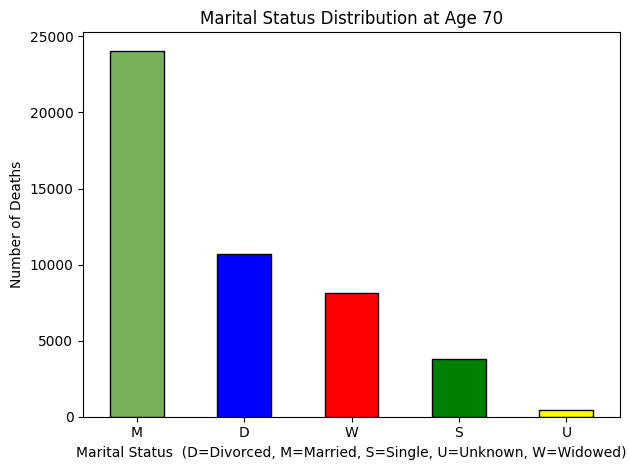

In [77]:
my_second_counts.plot(kind='bar', color=bar_colors, edgecolor='black')
plt.title('Marital Status Distribution at Age 70')
plt.xlabel('Marital Status  (D=Divorced, M=Married, S=Single, U=Unknown, W=Widowed)')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

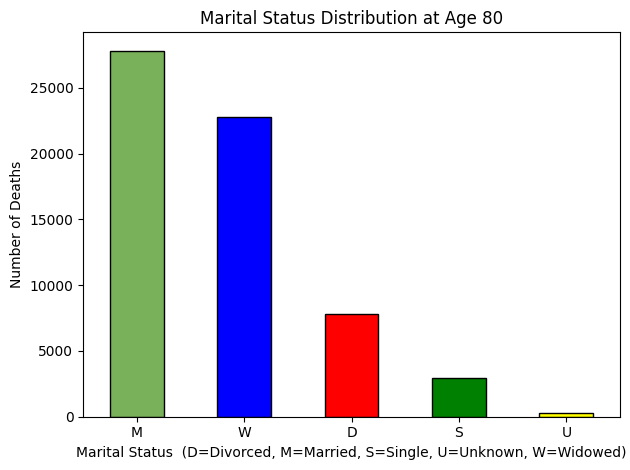

In [78]:
my_third_counts.plot(kind='bar', color=bar_colors, edgecolor='black')
plt.title('Marital Status Distribution at Age 80')
plt.xlabel('Marital Status  (D=Divorced, M=Married, S=Single, U=Unknown, W=Widowed)')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [79]:
monthly_counts = cleanDF['MonthOfDeath'].value_counts()
monthly_counts

MonthOfDeath
12    243797
1     243673
3     228823
11    221708
10    218512
5     217199
4     215909
2     212312
7     209699
8     208350
9     205607
6     205011
Name: count, dtype: int64

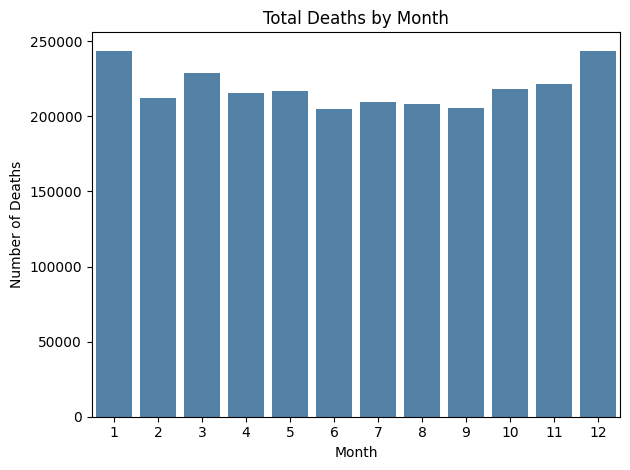

In [81]:
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, color='steelblue')
plt.title('Total Deaths by Month')
plt.xlabel('Month')
plt.ylabel('Number of Deaths')
plt.tight_layout()
plt.show()

5.1: See above.

5.2: Married increases, Widowed is the same at 60 and 70 but increases a lot at 80, Divorced increases at 70 but decreases again at 80, Single increases a tiny bit, and unknown looks like it stays about the same.

5.3: I plotted deaths by month because I thought it would be interesting to see when most people die. It seems like it's pretty stable throughout the year but has a slight spike in December and January, which makes sense because of the cold weather and flu season. I also think the dip during the summer is probably because most of the older people who would have been susceptible have already died during those winter months, but I'm sure there are other factors as well (like hotter weather being better at preventing sickness maybe?).

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
